# Post-hoc Error Analysis

**Frozen model, frozen predictions, diagnostic analysis only.**

This notebook asks where, how, and under what conditions `F_final_fcos_tuned` fails. It consumes the CPU prediction records persisted by notebook 07 and never reconstructs FCOS, loads `best.pth`, invokes the detector, or performs GPU inference.

$$
\text{notebook 07}
\rightarrow \texttt{test\_predictions.pt}
\rightarrow \text{CPU-only diagnostic taxonomy}
\rightarrow \text{deployment handoff}.
$$

## 1. Objective and methodological boundary

The purpose is not to improve the current test result or search for a better configuration. The final model and its operating point remain fixed at confidence $0.50$ and IoU $0.50$, read directly from notebook-07 artifacts. A descriptive localization interval of $0.10\leq\mathrm{IoU}<0.50$ is used only to distinguish weak spatial correspondence from background errors.

Low-confidence candidates are inspected diagnostically, never used to choose a new threshold. Observed test failure modes may motivate a future development cycle, but they do not trigger additional tuning of `F_final_fcos_tuned` in the current cycle. Once these test-set patterns influence future development, this split can no longer serve as a fresh unseen final holdout for that later cycle.

In [20]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image, ImageDraw

LOCALIZATION_IOU_FLOOR = 0.10
SMALL_OBJECT_AREA_THRESHOLD = 0.01
MEDIUM_OBJECT_AREA_THRESHOLD = 0.05
EXPECTED_EXPERIMENT_ID = "F_final_fcos_tuned"

CLASS_NAMES = {
    0: "Impacted",
    1: "Caries",
    2: "Periapical Lesion",
    3: "Deep Caries",
}
DETECTION_LABELS = [*CLASS_NAMES.values(), "Background / No Match"]

ROOT = Path.cwd().resolve()
if not (ROOT / "artifacts" / "final_evaluation").is_dir():
    ROOT = ROOT.parent

FINAL_DIR = ROOT / "artifacts" / "final_evaluation"
ERROR_DIR = ROOT / "artifacts" / "error_analysis"
FIGURE_DIR = ERROR_DIR / "figures"
TEST_IMAGES = ROOT / "data" / "processed" / "dentex_diagnosis" / "images" / "test"

ERROR_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

REPORT_BLUE = "#3B6EA8"
REPORT_ORANGE = "#E17C36"
REPORT_RED = "#C44E52"
REPORT_GREEN = "#4C956C"
REPORT_GRAY = "#7A7A7A"


def print_section(title, rows=None):
    print()
    print("=" * 72)
    print(title)
    print("=" * 72)
    if rows:
        width = max(len(str(label)) for label, _ in rows)
        for label, value in rows:
            print(f"{label:<{width}} : {value}")

## 2. Persisted prediction verification

In [21]:
def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)

def load_error_analysis_inputs():
    final_evaluation = load_json(FINAL_DIR / "final_model_evaluation.json")
    selected_model = load_json(
        ROOT / "artifacts" / "refinement" / "fcos" / "selected_final_model.json"
    )
    prediction_records = torch.load(
        FINAL_DIR / "test_predictions.pt",
        map_location="cpu",
        weights_only=False,
    )
    per_class_coco = pd.read_csv(FINAL_DIR / "per_class_test_metrics.csv")
    operating_point = load_json(FINAL_DIR / "operating_point_metrics.json")
    return final_evaluation, selected_model, prediction_records, per_class_coco, operating_point

FINAL_EVALUATION, SELECTED_MODEL, RECORDS, PER_CLASS_COCO, OPERATING_POINT = load_error_analysis_inputs()
CONFIDENCE_THRESHOLD = float(OPERATING_POINT["confidence_threshold"])
IOU_THRESHOLD = float(OPERATING_POINT["iou_match_threshold"])

print_section("POST-HOC ERROR ANALYSIS", [
    ("Final model", SELECTED_MODEL["selected_final_experiment_id"]),
    ("Prediction source", FINAL_DIR / "test_predictions.pt"),
    ("Images", len(RECORDS)),
    ("Confidence", f"{CONFIDENCE_THRESHOLD:.2f}"),
    ("IoU", f"{IOU_THRESHOLD:.2f}"),
    ("Model loaded", "NO"),
    ("GPU inference", "NO"),
    ("Status", "READY"),
])


POST-HOC ERROR ANALYSIS
Final model       : F_final_fcos_tuned
Prediction source : C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\final_evaluation\test_predictions.pt
Images            : 106
Confidence        : 0.50
IoU               : 0.50
Model loaded      : NO
GPU inference     : NO
Status            : READY


In [22]:
def validate_prediction_records(records, expected_count):
    if len(records) != int(expected_count):
        raise RuntimeError("Prediction count differs from the frozen evaluation.")
    required_record_keys = {"image_id", "file_name", "prediction", "target", "original_width", "original_height"}
    required_prediction_keys = {"boxes", "labels", "scores"}
    required_target_keys = {"boxes", "labels", "image_id"}
    image_ids = []
    for index, record in enumerate(records):
        missing = required_record_keys - record.keys()
        if missing:
            raise RuntimeError(f"Prediction record {index} lacks {sorted(missing)}.")
        if required_prediction_keys - record["prediction"].keys():
            raise RuntimeError(f"Prediction record {index} has an incomplete prediction payload.")
        if required_target_keys - record["target"].keys():
            raise RuntimeError(f"Prediction record {index} has an incomplete target payload.")
        prediction = record["prediction"]
        target = record["target"]
        if not (len(prediction["boxes"]) == len(prediction["labels"]) == len(prediction["scores"])):
            raise RuntimeError(f"Prediction tensor lengths disagree in record {index}.")
        if len(target["boxes"]) != len(target["labels"]):
            raise RuntimeError(f"Target tensor lengths disagree in record {index}.")
        prediction_labels = set(int(label) for label in prediction["labels"].tolist())
        target_labels = set(int(label) for label in target["labels"].tolist())
        valid_labels = set(range(1, len(CLASS_NAMES) + 1))
        if not prediction_labels.issubset(valid_labels) or not target_labels.issubset(valid_labels):
            raise RuntimeError(f"Unexpected class label in record {index}.")
        image_ids.append(int(record["image_id"]))
    if len(image_ids) != len(set(image_ids)):
        raise RuntimeError("Prediction image IDs are not unique.")
    return image_ids


def validate_cpu_predictions(records):
    devices = {
        value.device.type
        for record in records
        for group_name in ("prediction", "target")
        for value in record[group_name].values()
        if torch.is_tensor(value)
    }
    if devices != {"cpu"}:
        raise RuntimeError(f"Expected CPU-only prediction tensors, found {devices}.")
    return devices


def verify_frozen_analysis_inputs(records, final_evaluation, selected_model):
    required_paths = [
        FINAL_DIR / "test_predictions.pt",
        FINAL_DIR / "final_model_evaluation.json",
        FINAL_DIR / "operating_point_metrics.json",
        FINAL_DIR / "per_class_test_metrics.csv",
    ]
    missing_paths = [path for path in required_paths if not path.is_file()]
    if missing_paths:
        raise FileNotFoundError(f"Missing notebook-07 artifacts: {missing_paths}")
    if selected_model["selected_final_experiment_id"] != EXPECTED_EXPERIMENT_ID:
        raise RuntimeError("Selected-model identity mismatch.")
    if final_evaluation["selected_final_experiment_id"] != EXPECTED_EXPERIMENT_ID:
        raise RuntimeError("Final-evaluation identity mismatch.")
    if Path(selected_model["best_checkpoint"]).name != "best.pth":
        raise RuntimeError("Selected metadata does not identify best.pth.")
    persisted_operating_point = final_evaluation["operating_point"]
    if float(persisted_operating_point["confidence_threshold"]) != CONFIDENCE_THRESHOLD:
        raise RuntimeError("Confidence threshold differs from the frozen evaluation.")
    if float(persisted_operating_point["iou_match_threshold"]) != IOU_THRESHOLD:
        raise RuntimeError("IoU threshold differs from the frozen evaluation.")
    expected_classes = set(CLASS_NAMES.values())
    if set(PER_CLASS_COCO["class_name"]) != expected_classes:
        raise RuntimeError("Persisted class mapping differs from the canonical four classes.")
    image_ids = validate_prediction_records(records, final_evaluation["test_metrics"]["images"])
    devices = validate_cpu_predictions(records)
    return {"image_count": len(image_ids), "devices": devices, "status": "PASS"}


INPUT_AUDIT = verify_frozen_analysis_inputs(RECORDS, FINAL_EVALUATION, SELECTED_MODEL)
print_section("POST-HOC INPUT VERIFICATION", [
    ("Predictions", "test_predictions.pt"),
    ("Images", INPUT_AUDIT["image_count"]),
    ("Prediction device", ", ".join(sorted(INPUT_AUDIT["devices"])).upper()),
    ("Model loaded", "NO"),
    ("Inference rerun", "NO"),
    ("Checkpoint selected", "NO"),
    ("Status", INPUT_AUDIT["status"]),
])


POST-HOC INPUT VERIFICATION
Predictions         : test_predictions.pt
Images              : 106
Prediction device   : CPU
Model loaded        : NO
Inference rerun     : NO
Checkpoint selected : NO
Status              : PASS


The verified input comprises 106 unique records whose prediction and target tensors are all on CPU. The final evaluation identity and selected-model identity both resolve to `F_final_fcos_tuned`. This establishes the notebook boundary: analysis is reproducible from persisted inference results alone.

## 3. Diagnostic matching protocol

Notebook 07 uses a canonical same-class matcher: an accepted prediction becomes a true positive only when class agrees and IoU reaches $0.50$. Notebook 08 deliberately asks a different question. Accepted predictions are processed in descending confidence order and associated class-agnostically with the best unmatched ground-truth region. The association is then classified as:

- **true positive:** IoU $\geq0.50$ and class agreement;
- **classification error:** IoU $\geq0.50$ but wrong class;
- **duplicate detection:** IoU $\geq0.50$ with an already matched object;
- **localization error:** correct class and $0.10\leq\mathrm{IoU}<0.50$;
- **background false positive:** no qualifying association above;
- **false negative:** a ground-truth object remains unmatched.

Because a classification error can spatially consume a ground-truth object in the diagnostic taxonomy, its counts do not reconcile one-for-one with notebook 07's $TP=230$, $FP=181$, and $FN=309$. This is a semantic difference, not evidence that the frozen predictions changed.

`EXPECTED_HISTORICAL_EVENT_COUNTS` is a regression guard for this immutable prediction artifact. It verifies provenance; it does not define or override the computed taxonomy.


In [23]:
def box_iou(reference_box, candidate_boxes):
    if len(candidate_boxes) == 0:
        return torch.empty(0)

    intersection_size = (
        torch.minimum(reference_box[2:], candidate_boxes[:, 2:])
        - torch.maximum(reference_box[:2], candidate_boxes[:, :2])
    ).clamp(min=0)
    intersection_area = intersection_size.prod(dim=1)

    reference_area = (reference_box[2:] - reference_box[:2]).prod()
    candidate_areas = (candidate_boxes[:, 2:] - candidate_boxes[:, :2]).prod(dim=1)
    union_area = (reference_area + candidate_areas - intersection_area).clamp(min=1e-9)

    return intersection_area / union_area

def relative_bbox_area(record, bounding_box):
    bbox_width = float(bounding_box[2] - bounding_box[0])
    bbox_height = float(bounding_box[3] - bounding_box[1])
    image_area = record["original_width"] * record["original_height"]
    return bbox_width * bbox_height / image_area

def assign_size_category(relative_area):
    if relative_area < SMALL_OBJECT_AREA_THRESHOLD:
        return "small"
    if relative_area < MEDIUM_OBJECT_AREA_THRESHOLD:
        return "medium"
    return "large"

def class_name(torchvision_label):
    if torchvision_label == 0:
        return "Background / No Match"
    return CLASS_NAMES[torchvision_label - 1]

In [24]:
def classify_record(record):
    predictions = record["prediction"]
    targets = record["target"]

    accepted = predictions["scores"] >= CONFIDENCE_THRESHOLD
    accepted_indices = torch.nonzero(accepted, as_tuple=False).flatten()
    confidence_order = torch.argsort(
        predictions["scores"][accepted_indices],
        descending=True,
    )
    prediction_indices = accepted_indices[confidence_order]

    matched_ground_truth = set()
    events = []

    for prediction_index in prediction_indices.tolist():
        prediction_box = predictions["boxes"][prediction_index]
        predicted_label = int(predictions["labels"][prediction_index])
        confidence = float(predictions["scores"][prediction_index])
        ious = box_iou(prediction_box, targets["boxes"])

        unmatched_indices = [
            index for index in range(len(ious))
            if index not in matched_ground_truth
        ]
        best_unmatched = (
            max(unmatched_indices, key=lambda index: float(ious[index]))
            if unmatched_indices else None
        )

        if best_unmatched is not None and float(ious[best_unmatched]) >= IOU_THRESHOLD:
            ground_truth_index = best_unmatched
            matched_ground_truth.add(ground_truth_index)
            actual_label = int(targets["labels"][ground_truth_index])
            event_type = (
                "true_positive"
                if actual_label == predicted_label
                else "classification_error"
            )
        else:
            best_any = int(torch.argmax(ious)) if len(ious) else None
            ground_truth_index = best_any
            best_iou = float(ious[best_any]) if best_any is not None else 0.0
            actual_label = (
                int(targets["labels"][best_any])
                if best_any is not None else 0
            )

            if best_any in matched_ground_truth and best_iou >= IOU_THRESHOLD:
                event_type = "duplicate_detection"
            elif (
                best_any is not None
                and actual_label == predicted_label
                and LOCALIZATION_IOU_FLOOR <= best_iou < IOU_THRESHOLD
            ):
                event_type = "localization_error"
            else:
                event_type = "background_false_positive"

        events.append(
            {
                "image_id": record["image_id"],
                "file_name": record["file_name"],
                "event_type": event_type,
                "prediction_index": prediction_index,
                "predicted_label": predicted_label,
                "actual_label": actual_label,
                "confidence": confidence,
                "iou": (
                    float(ious[ground_truth_index])
                    if ground_truth_index is not None else 0.0
                ),
                "prediction_box": prediction_box.tolist(),
                "gt_index": ground_truth_index,
            }
        )

    for ground_truth_index, (ground_truth_box, actual_label) in enumerate(
        zip(targets["boxes"], targets["labels"])
    ):
        if ground_truth_index in matched_ground_truth:
            continue

        candidate_ious = box_iou(ground_truth_box, predictions["boxes"])
        best_prediction_index = (
            int(torch.argmax(candidate_ious))
            if len(candidate_ious) else None
        )
        relative_area = relative_bbox_area(record, ground_truth_box)

        events.append(
            {
                "image_id": record["image_id"],
                "file_name": record["file_name"],
                "event_type": "false_negative",
                "prediction_index": best_prediction_index,
                "predicted_label": (
                    int(predictions["labels"][best_prediction_index])
                    if best_prediction_index is not None else 0
                ),
                "actual_label": int(actual_label),
                "confidence": (
                    float(predictions["scores"][best_prediction_index])
                    if best_prediction_index is not None else 0.0
                ),
                "iou": (
                    float(candidate_ious[best_prediction_index])
                    if best_prediction_index is not None else 0.0
                ),
                "prediction_box": (
                    predictions["boxes"][best_prediction_index].tolist()
                    if best_prediction_index is not None else None
                ),
                "gt_index": ground_truth_index,
                "gt_box": ground_truth_box.tolist(),
                "relative_bbox_area": relative_area,
                "size_category": assign_size_category(relative_area),
            }
        )

    return events

def build_detection_events(records):
    all_events = []
    for record in records:
        all_events.extend(classify_record(record))
    return pd.DataFrame(all_events)

### 3.1 Tabular diagnostic extraction


In [25]:
def build_per_class_error_table(final_evaluation, per_class_coco):
    operating_point = pd.DataFrame(
        final_evaluation["operating_point"]["per_class"]
    )
    table = operating_point.merge(
        per_class_coco,
        on=["class_id", "class_name"],
    )
    table["GT count"] = table["TP"] + table["FN"]
    table["FP per GT"] = table["FP"] / table["GT count"]
    table["FN rate"] = table["FN"] / table["GT count"]
    table["share total FP"] = table["FP"] / table["FP"].sum()
    table["share total FN"] = table["FN"] / table["FN"].sum()
    return table


def build_gt_object_table(records, events):
    true_positive_keys = {
        (int(row.image_id), int(row.gt_index))
        for _, row in events[events.event_type == "true_positive"].iterrows()
    }
    rows = []

    for record in records:
        for ground_truth_index, (bounding_box, label) in enumerate(
            zip(record["target"]["boxes"], record["target"]["labels"])
        ):
            relative_area = relative_bbox_area(record, bounding_box)
            rows.append(
                {
                    "image_id": record["image_id"],
                    "gt_index": ground_truth_index,
                    "class_name": class_name(int(label)),
                    "relative_bbox_area": relative_area,
                    "size_category": assign_size_category(relative_area),
                    "tp": int(
                        (record["image_id"], ground_truth_index)
                        in true_positive_keys
                    ),
                }
            )

    return pd.DataFrame(rows)


def build_size_analysis(gt_objects):
    table = (
        gt_objects.groupby("size_category")
        .agg(gt_count=("tp", "size"), tp=("tp", "sum"))
        .reindex(["small", "medium", "large"])
        .fillna(0)
        .reset_index()
    )
    table["fn"] = table["gt_count"] - table["tp"]
    table["recall"] = table["tp"] / table["gt_count"].replace(0, np.nan)
    return table


def build_false_positive_table(events):
    false_positive_types = [
        "background_false_positive",
        "duplicate_detection",
        "localization_error",
    ]
    table = events[events.event_type.isin(false_positive_types)].copy()
    table["predicted_class"] = table.predicted_label.map(class_name)
    table["closest_gt_class"] = table.actual_label.map(class_name)
    return table.sort_values("confidence", ascending=False)


def build_false_negative_table(events):
    table = events[events.event_type == "false_negative"].copy()
    table["gt_class"] = table.actual_label.map(class_name)
    table["best_prediction_class"] = table.predicted_label.map(class_name)

    low_confidence = table.confidence < CONFIDENCE_THRESHOLD
    no_spatial_match = table.iou < LOCALIZATION_IOU_FLOOR
    table["diagnostic_reason"] = np.select(
        [low_confidence, no_spatial_match],
        [
            "best candidate below fixed confidence",
            "no meaningful spatial correspondence",
        ],
        default="unmatched or spatially misclassified",
    )
    return table


def build_image_difficulty_table(records, events):
    rows = []
    event_columns = [
        "true_positive", "false_negative", "background_false_positive",
        "classification_error", "localization_error", "duplicate_detection",
    ]
    for record in records:
        image_events = events[events.image_id == record["image_id"]]
        counts = image_events.event_type.value_counts()
        row = {
            "image_id": int(record["image_id"]),
            "file_name": record["file_name"],
            "GT count": len(record["target"]["boxes"]),
            "candidate predictions": len(record["prediction"]["boxes"]),
            "accepted predictions": int((record["prediction"]["scores"] >= CONFIDENCE_THRESHOLD).sum()),
        }
        row.update({column: int(counts.get(column, 0)) for column in event_columns})
        row["total diagnostic errors"] = sum(row[column] for column in event_columns if column != "true_positive")
        row["diagnostic recall"] = row["true_positive"] / row["GT count"] if row["GT count"] else np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values(
        ["total diagnostic errors", "false_negative", "background_false_positive"],
        ascending=False,
    )


def build_prediction_confidence_table(records):
    rows = []
    for record in records:
        predictions = record["prediction"]
        for label, score in zip(predictions["labels"], predictions["scores"]):
            rows.append({
                "image_id": int(record["image_id"]),
                "predicted_class": class_name(int(label)),
                "confidence": float(score),
                "above_fixed_threshold": float(score) >= CONFIDENCE_THRESHOLD,
            })
    return pd.DataFrame(rows)


def build_classification_confusion_matrix(events):
    class_labels = list(CLASS_NAMES.values())
    matrix = pd.DataFrame(0, index=class_labels, columns=class_labels, dtype=int)
    errors = events[events.event_type == "classification_error"]
    for _, event in errors.iterrows():
        matrix.loc[class_name(int(event.actual_label)), class_name(int(event.predicted_label))] += 1
    return matrix


def build_tp_localization_summary(events):
    true_positives = events[events.event_type == "true_positive"].copy()
    true_positives["class_name"] = true_positives.actual_label.map(class_name)
    return (
        true_positives.groupby("class_name", sort=False)["iou"]
        .agg(TP_count="count", median_TP_IoU="median")
        .reindex(CLASS_NAMES.values())
        .reset_index()
    )


def build_true_positive_iou_table(events):
    table = events[events.event_type == "true_positive"].copy()
    table["class_name"] = table.actual_label.map(class_name)
    return table[["image_id", "class_name", "confidence", "iou"]].reset_index(drop=True)

### 3.2 Diagnostic aggregation


In [26]:
EVENT_ORDER = [
    "true_positive", "false_negative", "background_false_positive",
    "classification_error", "localization_error", "duplicate_detection",
]
EVENT_LABELS = {
    "true_positive": "True Positive",
    "false_negative": "False Negative",
    "background_false_positive": "Background False Positive",
    "classification_error": "Classification Error",
    "localization_error": "Localization Error",
    "duplicate_detection": "Duplicate Detection",
}


def aggregate_error_taxonomy(events):
    counts = events.event_type.value_counts()
    return pd.DataFrame({
        "event_type": EVENT_ORDER,
        "Event": [EVENT_LABELS[event] for event in EVENT_ORDER],
        "Count": [int(counts.get(event, 0)) for event in EVENT_ORDER],
    })


def aggregate_per_class_diagnostics(final_evaluation, per_class_coco):
    table = build_per_class_error_table(final_evaluation, per_class_coco)
    columns = ["class_name", "GT count", "TP", "FP", "FN", "Precision", "Recall", "F1", "FN rate"]
    return table, table[columns].copy()


def aggregate_false_negative_diagnostics(events, per_class_view):
    false_negatives = build_false_negative_table(events)
    by_class = (
        false_negatives.groupby("gt_class").size()
        .reindex(CLASS_NAMES.values(), fill_value=0)
        .rename("FN").reset_index().rename(columns={"gt_class": "Class"})
    )
    by_class = by_class.merge(
        per_class_view[["class_name", "GT count", "FN rate"]],
        left_on="Class", right_on="class_name",
    ).drop(columns="class_name")
    by_size = (
        false_negatives.groupby("size_category").size()
        .reindex(["small", "medium", "large"], fill_value=0)
        .rename("FN").reset_index()
    )
    return false_negatives, by_class, by_size


def aggregate_false_positive_diagnostics(events, per_class_view):
    false_positives = build_false_positive_table(events)
    by_type_and_class = (
        false_positives.groupby(["predicted_class", "event_type"]).size()
        .rename("count").reset_index()
    )
    canonical_total = int(per_class_view.FP.sum())
    caries_count = int(per_class_view.loc[per_class_view.class_name == "Caries", "FP"].iloc[0])
    return false_positives, by_type_and_class, canonical_total, caries_count / canonical_total


def aggregate_size_diagnostics(records, events):
    gt_objects = build_gt_object_table(records, events)
    return gt_objects, build_size_analysis(gt_objects)


def aggregate_classification_localization(events):
    classification_errors = events[events.event_type == "classification_error"].sort_values(["confidence", "iou"], ascending=False)
    localization_errors = events[events.event_type == "localization_error"].sort_values(["confidence", "iou"], ascending=[False, True])
    confusion = build_classification_confusion_matrix(events)
    tp_iou = build_true_positive_iou_table(events)
    tp_localization = (
        tp_iou.groupby("class_name", sort=False)["iou"]
        .agg(TP_count="count", median_TP_IoU="median")
        .reindex(CLASS_NAMES.values()).reset_index()
    )
    return classification_errors, localization_errors, confusion, tp_iou, tp_localization


def aggregate_confidence_diagnostics(records):
    confidence_table = build_prediction_confidence_table(records)
    grouped = confidence_table.groupby("predicted_class")
    summary = (
        grouped.confidence.agg(predictions="count", median="median", mean="mean", maximum="max")
        .reindex(CLASS_NAMES.values()).reset_index()
    )
    survival = (
        grouped.agg(
            candidate_predictions=("confidence", "size"),
            accepted_predictions=("above_fixed_threshold", "sum"),
        )
        .reindex(CLASS_NAMES.values()).reset_index()
    )
    survival["survival_fraction"] = survival.accepted_predictions / survival.candidate_predictions
    periapical = confidence_table[confidence_table.predicted_class == "Periapical Lesion"]
    below = int((periapical.confidence < CONFIDENCE_THRESHOLD).sum())
    return confidence_table, summary, survival, len(periapical), below


def aggregate_diagnostic_prediction_errors(events):
    error_types = [
        "background_false_positive", "classification_error",
        "localization_error", "duplicate_detection",
    ]
    counts = events[events.event_type.isin(error_types)].event_type.value_counts()
    return pd.DataFrame({
        "event_type": error_types,
        "Event": [EVENT_LABELS[event] for event in error_types],
        "Count": [int(counts.get(event, 0)) for event in error_types],
    })

### 3.3 Quantitative visualization


In [27]:
def plot_error_taxonomy(taxonomy):
    plot_data = taxonomy.iloc[::-1]
    colors = [REPORT_RED if event == "false_negative" else REPORT_BLUE for event in plot_data.event_type]
    figure, axis = plt.subplots(figsize=(8.5, 4.8))
    bars = axis.barh(plot_data.Event, plot_data.Count, color=colors)
    axis.bar_label(bars, padding=5)
    axis.set(title="Frozen-detector diagnostic event taxonomy", xlabel="Event count", ylabel="")
    axis.grid(axis="x", alpha=0.25)
    axis.grid(axis="y", visible=False)
    figure.tight_layout()
    plt.show()


def plot_per_class_metrics(per_class_view):
    width = 0.24
    x = np.arange(len(CLASS_NAMES))
    figure, axis = plt.subplots(figsize=(10, 4.8))
    indexed = per_class_view.set_index("class_name")
    for offset, metric, color in zip([-width, 0, width], ["Precision", "Recall", "F1"], [REPORT_BLUE, REPORT_ORANGE, REPORT_GREEN]):
        axis.bar(x + offset, indexed.loc[list(CLASS_NAMES.values()), metric], width=width, label=metric, color=color)
    axis.set_xticks(x, list(CLASS_NAMES.values()), rotation=15)
    axis.set(title="Per-class fixed operating-point performance", ylabel="Metric value", xlabel="", ylim=(0, 1.08))
    axis.legend(frameon=False, ncol=3)
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()


def plot_false_negative_count(by_class):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    bars = axis.bar(by_class.Class, by_class.FN, color=REPORT_RED)
    axis.bar_label(bars, padding=4)
    axis.set(title="False-negative count by class", xlabel="", ylabel="FN count")
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()


def plot_false_negative_rate(by_class):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    bars = axis.bar(by_class.Class, by_class["FN rate"], color=REPORT_ORANGE)
    axis.bar_label(bars, labels=[f"{value:.4f}" for value in by_class["FN rate"]], padding=4)
    axis.set(title="Miss rate by class at the frozen operating point", xlabel="", ylabel="FN / GT", ylim=(0, 1.08))
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()




def plot_size_recall_clean(size_analysis):
    plot_data = size_analysis[size_analysis.gt_count > 0]
    figure, axis = plt.subplots(figsize=(6.5, 4.2))
    bars = axis.bar(plot_data.size_category.str.title(), plot_data.recall, color=[REPORT_RED, REPORT_BLUE])
    axis.bar_label(bars, labels=[f"{value:.4f}" for value in plot_data.recall], padding=4)
    axis.set(title="Recall by project-level relative box area", xlabel="Size category", ylabel="Recall", ylim=(0, 0.55))
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()


def plot_classification_confusion(confusion):
    figure, axis = plt.subplots(figsize=(7.2, 5.8))
    image = axis.imshow(confusion, cmap="Blues", vmin=0)
    axis.set_xticks(range(4), confusion.columns, rotation=25, ha="right")
    axis.set_yticks(range(4), confusion.index)
    axis.set(title="Spatially matched classification errors", xlabel="Predicted class", ylabel="Ground-truth class")
    for row in range(4):
        for column in range(4):
            axis.text(column, row, int(confusion.iloc[row, column]), ha="center", va="center")
    figure.colorbar(image, ax=axis, fraction=0.046)
    figure.tight_layout()
    plt.show()




def plot_confidence_ecdfs(confidence_table):
    figure, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    for axis, class_label in zip(axes.flat, CLASS_NAMES.values()):
        values = np.sort(confidence_table.loc[confidence_table.predicted_class == class_label, "confidence"].to_numpy())
        cumulative = np.arange(1, len(values) + 1) / len(values)
        axis.plot(values, cumulative, color=REPORT_BLUE, linewidth=2)
        axis.axvline(CONFIDENCE_THRESHOLD, color=REPORT_RED, linestyle="--", linewidth=1.5)
        axis.set_title(f"{class_label} (n={len(values)})")
        axis.set_xlabel("Confidence")
        axis.set_ylabel("Cumulative share")
        axis.grid(alpha=0.2)
    figure.suptitle("Frozen prediction-confidence ECDFs", fontsize=13)
    figure.tight_layout()
    plt.show()


def plot_canonical_false_positives(per_class_view):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    bars = axis.bar(per_class_view.class_name, per_class_view.FP, color=REPORT_RED)
    axis.bar_label(bars, padding=4)
    axis.set(title="False positives by predicted class", xlabel="", ylabel="Canonical FP count")
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()


def plot_diagnostic_fp_taxonomy(summary):
    figure, axis = plt.subplots(figsize=(8, 4.5))
    bars = axis.barh(summary.Event.iloc[::-1], summary.Count.iloc[::-1], color=REPORT_BLUE)
    axis.bar_label(bars, padding=4)
    axis.set(title="Diagnostic prediction-error taxonomy", xlabel="Event count", ylabel="")
    axis.grid(axis="x", alpha=0.25)
    axis.grid(axis="y", visible=False)
    figure.tight_layout()
    plt.show()


def plot_tp_iou_distribution(tp_iou):
    ordered = list(CLASS_NAMES.values())
    values = [tp_iou.loc[tp_iou.class_name == name, "iou"].to_numpy() for name in ordered]
    counts = [len(value) for value in values]
    figure, axis = plt.subplots(figsize=(9, 4.8))
    axis.boxplot(values, tick_labels=[f"{name}\n(n={count})" for name, count in zip(ordered, counts)], showfliers=False)
    axis.set(title="True-positive IoU distribution by class", xlabel="", ylabel="IoU", ylim=(0.45, 1.02))
    axis.grid(axis="y", alpha=0.25)
    figure.tight_layout()
    plt.show()


def plot_confidence_survival(survival):
    figure, axis = plt.subplots(figsize=(8.5, 4.5))
    bars = axis.bar(survival.predicted_class, survival.survival_fraction, color=REPORT_BLUE)
    labels = [f"{fraction:.1%}\n({int(accepted)}/{int(total)})" for fraction, accepted, total in zip(
        survival.survival_fraction, survival.accepted_predictions, survival.candidate_predictions
    )]
    axis.bar_label(bars, labels=labels, padding=4, fontsize=9)
    axis.set(title=f"Prediction survival at confidence ≥ {CONFIDENCE_THRESHOLD:.2f}", xlabel="", ylabel="Accepted / candidates", ylim=(0, max(0.12, survival.survival_fraction.max() * 1.25)))
    axis.tick_params(axis="x", rotation=15)
    axis.grid(axis="y", alpha=0.25)
    axis.grid(axis="x", visible=False)
    figure.tight_layout()
    plt.show()


def plot_image_error_burden(image_difficulty, top_n=10):
    components = [
        ("false_negative", "False Negative", REPORT_RED),
        ("background_false_positive", "Background FP", REPORT_ORANGE),
        ("classification_error", "Classification", REPORT_BLUE),
        ("localization_error", "Localization", REPORT_GREEN),
        ("duplicate_detection", "Duplicate", REPORT_GRAY),
    ]
    top = image_difficulty.head(top_n).iloc[::-1].copy()
    labels = [f"{int(row.image_id)} | {row.file_name}" for row in top.itertuples()]
    left = np.zeros(len(top))
    figure, axis = plt.subplots(figsize=(10, 5.8))
    for column, label, color in components:
        values = top[column].to_numpy()
        axis.barh(labels, values, left=left, label=label, color=color)
        left += values
    axis.set(title=f"Test images with the highest diagnostic error burden (top {top_n})", xlabel="Diagnostic event count", ylabel="")
    axis.legend(frameon=False, ncol=3, loc="lower right")
    axis.grid(axis="x", alpha=0.25)
    axis.grid(axis="y", visible=False)
    figure.tight_layout()
    plt.show()

### 3.4 Qualitative case selection and rendering


In [28]:
def select_representative_cases(events, records):
    record_lookup = {int(record["image_id"]): record for record in records}
    counts = events.groupby("image_id").event_type.value_counts().unstack(fill_value=0)
    for column in EVENT_ORDER:
        if column not in counts:
            counts[column] = 0
    counts["prediction_side_errors"] = counts[[
        "background_false_positive", "classification_error",
        "localization_error", "duplicate_detection",
    ]].sum(axis=1)
    counts["total_errors"] = counts["prediction_side_errors"] + counts["false_negative"]

    clean = counts[counts.total_errors == 0]
    tp_image = int((clean if len(clean) else counts).true_positive.idxmax())
    fn_image = int(counts.false_negative.idxmax())
    fp_image = int(counts.prediction_side_errors.idxmax())

    def first_event(image_id, event_types, sort="confidence", ascending=False):
        frame = events[(events.image_id == image_id) & events.event_type.isin(event_types)]
        return frame.sort_values(sort, ascending=ascending).iloc[0]

    periapical = events[(events.event_type == "false_negative") & (events.actual_label == 3)].sort_values("confidence", ascending=False).iloc[0]
    small = events[(events.event_type == "false_negative") & (events.size_category == "small")].sort_values("relative_bbox_area").iloc[0]
    caries_errors = events[
        (events.predicted_label == 2)
        & events.event_type.isin(["background_false_positive", "classification_error", "localization_error", "duplicate_detection"])
    ]
    caries_image = int(caries_errors.groupby("image_id").size().idxmax())

    selected = [
        ("Strongest clean true-positive image", first_event(tp_image, ["true_positive"])),
        ("Highest false-negative image", first_event(fn_image, ["false_negative"], sort="relative_bbox_area", ascending=True)),
        ("Highest prediction-error image", first_event(fp_image, ["background_false_positive", "classification_error", "localization_error", "duplicate_detection"])),
        ("Periapical false-negative", periapical),
        ("Caries false-positive-heavy image", caries_errors[caries_errors.image_id == caries_image].sort_values("confidence", ascending=False).iloc[0]),
        ("Classification-error case", events[events.event_type == "classification_error"].sort_values("confidence", ascending=False).iloc[0]),
        ("Localization-error case", events[events.event_type == "localization_error"].sort_values("iou").iloc[0]),
        ("Small-object miss", small),
    ]
    rows = []
    for reason, event in selected:
        row = event.to_dict()
        row["selection_reason"] = reason
        row["record"] = record_lookup[int(event.image_id)]
        rows.append(row)
    return rows

In [29]:
BOX_COLORS = {
    "normal": "#00D084",
    "highlight": "#FFD400",
    "prediction": "#FF4D4D",
}


def draw_boxes(image, boxes, labels, confidences=None, highlight_index=None):
    annotated = image.copy()
    drawer = ImageDraw.Draw(annotated)
    for index, (box, label) in enumerate(zip(boxes, labels)):
        highlighted = index == highlight_index
        color = BOX_COLORS["highlight"] if highlighted else BOX_COLORS["normal"]
        drawer.rectangle([float(value) for value in box], outline=color, width=5 if highlighted else 2)
        label_text = class_name(int(label))
        if confidences is not None:
            label_text += f" {float(confidences[index]):.2f}"
        drawer.text((float(box[0]), float(box[1])), label_text, fill=color)
    return annotated


def render_ground_truth(record, event):
    highlight = int(event["gt_index"]) if pd.notna(event.get("gt_index")) else None
    image = Image.open(TEST_IMAGES / record["file_name"]).convert("RGB")
    return draw_boxes(image, record["target"]["boxes"], record["target"]["labels"], highlight_index=highlight)


def render_predictions(record, event):
    predictions = record["prediction"]
    accepted = predictions["scores"] >= CONFIDENCE_THRESHOLD
    accepted_indices = torch.nonzero(accepted, as_tuple=False).flatten()
    highlight = None
    if pd.notna(event.get("prediction_index")):
        matches = torch.nonzero(accepted_indices == int(event["prediction_index"]), as_tuple=False).flatten()
        if len(matches):
            highlight = int(matches[0])
    image = Image.open(TEST_IMAGES / record["file_name"]).convert("RGB")
    return draw_boxes(
        image,
        predictions["boxes"][accepted],
        predictions["labels"][accepted],
        predictions["scores"][accepted],
        highlight_index=highlight,
    )


def plot_case_gallery(cases, output_path, rows_per_figure=4):
    for page, start in enumerate(range(0, len(cases), rows_per_figure), start=1):
        page_cases = cases[start:start + rows_per_figure]
        figure, axes = plt.subplots(len(page_cases), 3, figsize=(15, 4.2 * len(page_cases)))
        axes = np.atleast_2d(axes)
        for row, case in enumerate(page_cases):
            record = case["record"]
            original = Image.open(TEST_IMAGES / record["file_name"]).convert("RGB")
            panels = [original, render_ground_truth(record, case), render_predictions(record, case)]
            titles = ["Original", "Ground truth", f"Prediction @ {CONFIDENCE_THRESHOLD:.2f}"]
            for axis, panel, title in zip(axes[row], panels, titles):
                axis.imshow(panel)
                axis.set_title(title)
                axis.axis("off")
            metadata = f'{case["selection_reason"]} | image {case["image_id"]} | {record["file_name"]} | event={case["event_type"]}'
            axes[row, 0].set_ylabel(metadata, rotation=0, ha="right", va="center", labelpad=10, fontsize=9)
        figure.suptitle("Representative frozen-prediction diagnostic cases", fontsize=14, y=1.0)
        figure.tight_layout()
        figure.savefig(output_path.with_name(f"{output_path.stem}_{page:02d}.png"), dpi=130, bbox_inches="tight")
        plt.show()
        plt.close(figure)


In [30]:
def save_error_analysis_artifacts(
    event_taxonomy, per_class, false_negatives, false_positive_summary,
    false_positives, size_analysis, classification_confusion,
    classification_errors, localization_errors, tp_iou_summary,
    confidence_summary, confidence_survival, image_difficulty,
    qualitative_cases, summary,
):
    event_taxonomy.to_csv(ERROR_DIR / "event_taxonomy.csv", index=False)
    per_class.to_csv(ERROR_DIR / "per_class_error_summary.csv", index=False)
    false_negatives.to_csv(ERROR_DIR / "false_negatives.csv", index=False)
    false_positive_summary.to_csv(ERROR_DIR / "false_positive_summary.csv", index=False)
    false_positives.to_csv(ERROR_DIR / "false_positives.csv", index=False)
    size_analysis.to_csv(ERROR_DIR / "size_analysis.csv", index=False)
    classification_confusion.to_csv(ERROR_DIR / "classification_confusion.csv")
    classification_errors.to_csv(ERROR_DIR / "classification_errors.csv", index=False)
    localization_errors.to_csv(ERROR_DIR / "localization_errors.csv", index=False)
    tp_iou_summary.to_csv(ERROR_DIR / "tp_iou_summary.csv", index=False)
    confidence_summary.to_csv(ERROR_DIR / "confidence_summary.csv", index=False)
    confidence_survival.to_csv(ERROR_DIR / "confidence_survival.csv", index=False)
    image_difficulty.to_csv(ERROR_DIR / "image_difficulty.csv", index=False)
    qualitative_cases.to_csv(ERROR_DIR / "qualitative_cases.csv", index=False)
    with (ERROR_DIR / "error_summary.json").open("w", encoding="utf-8") as handle:
        json.dump(summary, handle, indent=2)

In [31]:
EVENTS = build_detection_events(RECORDS)
EXPECTED_HISTORICAL_EVENT_COUNTS = {
    "true_positive": 222,
    "false_negative": 279,
    "background_false_positive": 100,
    "classification_error": 38,
    "localization_error": 34,
    "duplicate_detection": 17,
}
ACTUAL_EVENT_COUNTS = EVENTS.event_type.value_counts().to_dict()
if ACTUAL_EVENT_COUNTS != EXPECTED_HISTORICAL_EVENT_COUNTS:
    raise RuntimeError(f"Diagnostic taxonomy changed: {ACTUAL_EVENT_COUNTS}")
print_section("DIAGNOSTIC MATCHING VERIFICATION", [
    ("Taxonomy events", len(EVENTS)),
    ("Historical counts", "MATCH"),
    ("Status", "PASS"),
])


DIAGNOSTIC MATCHING VERIFICATION
Taxonomy events   : 690
Historical counts : MATCH
Status            : PASS


## 4. Overall error taxonomy

**Question.** Which diagnostic event types dominate?

**Method.** Aggregate the immutable event table by mutually defined event category.

The event taxonomy separates correct detections from distinct diagnostic failure modes. It is the single downstream source for class, confidence, IoU, false-positive, false-negative, and qualitative analyses.

Event,Count
True Positive,222
False Negative,279
Background False Positive,100
Classification Error,38
Localization Error,34
Duplicate Detection,17


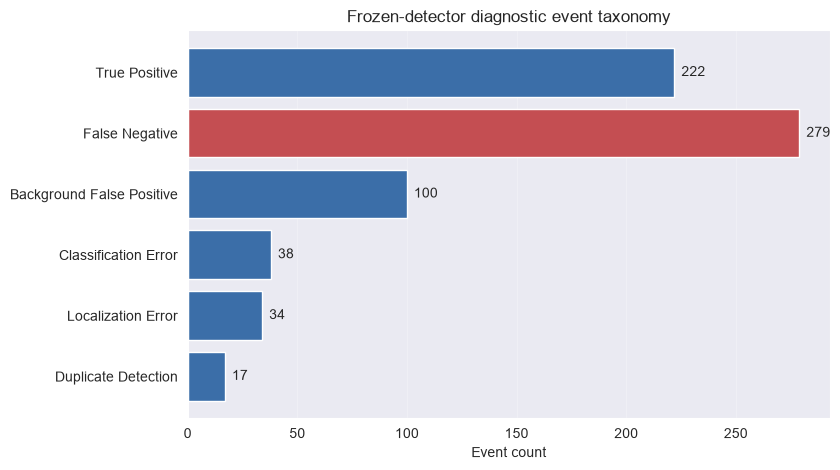

In [32]:
ERROR_TAXONOMY = aggregate_error_taxonomy(EVENTS)
display(ERROR_TAXONOMY[["Event", "Count"]].style.hide(axis="index"))
plot_error_taxonomy(ERROR_TAXONOMY)

**Interpretation.** False negatives dominate with 279 unmatched ground-truth objects. Background false positives are the largest prediction-side category at 100; classification errors (38), localization errors (34), and duplicates (17) are smaller. The primary limitation is therefore missed pathology, not systematic coordinate regression alone.

## 5. Per-class error analysis

**Question.** Which pathology classes are detected reliably, and which are missed?

**Method.** Combine frozen operating-point counts with persisted class metrics.

The canonical operating-point table from notebook 07 supplies same-class TP, FP, and FN values. FN rate is $FN/(TP+FN)$. This table is used for class-level operating behavior; the diagnostic taxonomy remains separate.

class_name,GT count,TP,FP,FN,Precision,Recall,F1,FN rate
Impacted,96,74,9,22,0.8916,0.7708,0.8268,0.2292
Caries,333,130,151,203,0.4626,0.3904,0.4235,0.6096
Periapical Lesion,26,2,0,24,1.0000,0.0769,0.1429,0.9231
Deep Caries,84,24,21,60,0.5333,0.2857,0.3721,0.7143


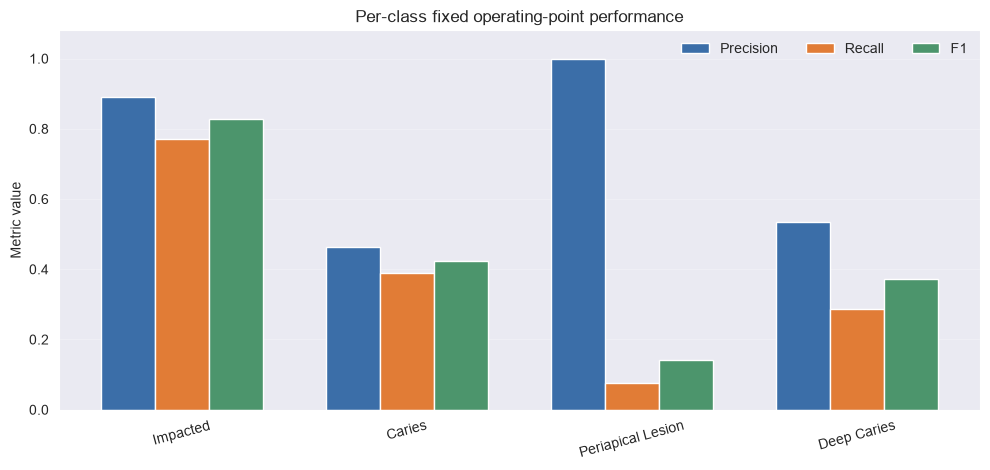

In [33]:
PER_CLASS, PER_CLASS_VIEW = aggregate_per_class_diagnostics(FINAL_EVALUATION, PER_CLASS_COCO)
display(PER_CLASS_VIEW.style.format({"Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}", "FN rate": "{:.4f}"}).hide(axis="index"))
plot_per_class_metrics(PER_CLASS_VIEW)

**Interpretation.** Impacted is the most stable class, with Precision 0.8916, Recall 0.7708, and FN rate 0.2292. Caries Recall falls to 0.3904 and Deep Caries to 0.2857. Periapical Lesion is the extreme failure: only 2 of 26 objects are detected, so

$$
\mathrm{Recall}_{\text{Periapical}}=\frac{2}{26}=0.0769,
$$

and its FN rate is 0.9231. Precision is numerically 1.0 only because two accepted predictions were correct and none was an accepted false positive. It is not good overall performance; almost all true Periapical lesions were missed.

## 6. False-negative analysis

**Question.** Where do missed ground-truth objects concentrate?

**Method.** Aggregate unmatched ground-truth events by class and project-level size category.

False negatives are analyzed by class, project-level object size, and representative image. The diagnostic reason describes the closest frozen candidate; it does not revise matching or suggest an alternative test threshold.

Class,FN,GT count,FN rate
Impacted,21,96,0.2292
Caries,199,333,0.6096
Periapical Lesion,18,26,0.9231
Deep Caries,41,84,0.7143


size_category,FN
small,109
medium,170
large,0


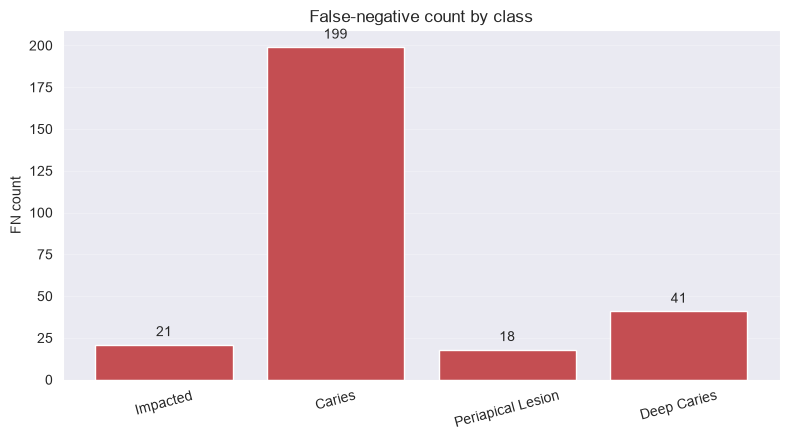

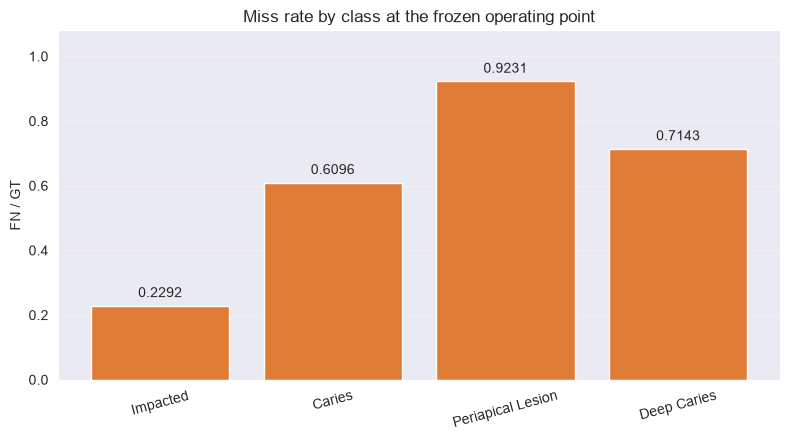

In [34]:
FALSE_NEGATIVES, FN_BY_CLASS, FN_BY_SIZE = aggregate_false_negative_diagnostics(EVENTS, PER_CLASS_VIEW)
display(FN_BY_CLASS.style.format({"FN rate": "{:.4f}"}).hide(axis="index"))
display(FN_BY_SIZE.style.hide(axis="index"))
plot_false_negative_count(FN_BY_CLASS)
plot_false_negative_rate(FN_BY_CLASS)

**Interpretation.** Misses concentrate numerically in Caries because it supplies the largest ground-truth volume, while Periapical Lesion has the highest proportional miss rate. Small and medium misses must be interpreted with their denominators, addressed in the size section below.

## 7. False-positive analysis

**Question.** Which classes and diagnostic mechanisms generate prediction-side errors?

**Method.** Keep canonical same-class FP counts separate from class-agnostic diagnostic categories.

The diagnostic taxonomy separates background false positives, duplicate detections, and localization errors. Classification errors are high-overlap wrong-class associations and are analyzed separately. For compatibility with the final operating-point report, canonical FP counts by predicted class are also retained.

**Semantic boundary.** The canonical class plot uses notebook 07's same-class fixed-point FP counts. The subsequent diagnostic plots use class-agnostic association to divide prediction-side failures into background, classification, localization, and duplicate events. These views must not be summed as if they used identical matching rules.

class_name,FP
Impacted,9
Caries,151
Periapical Lesion,0
Deep Caries,21


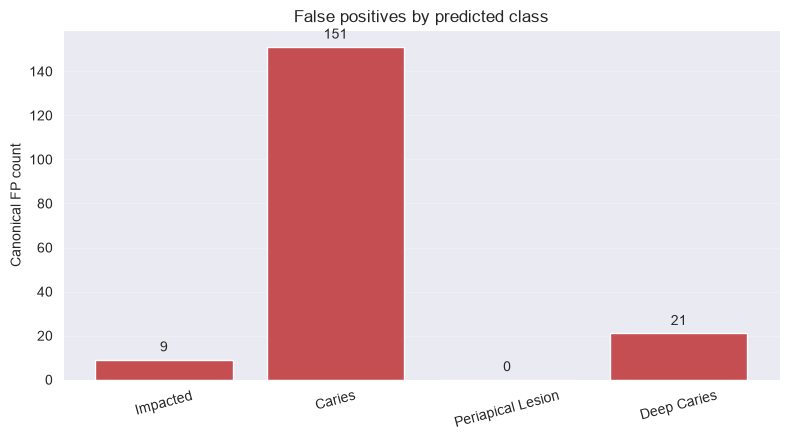

Event,Count
Background False Positive,100
Classification Error,38
Localization Error,34
Duplicate Detection,17


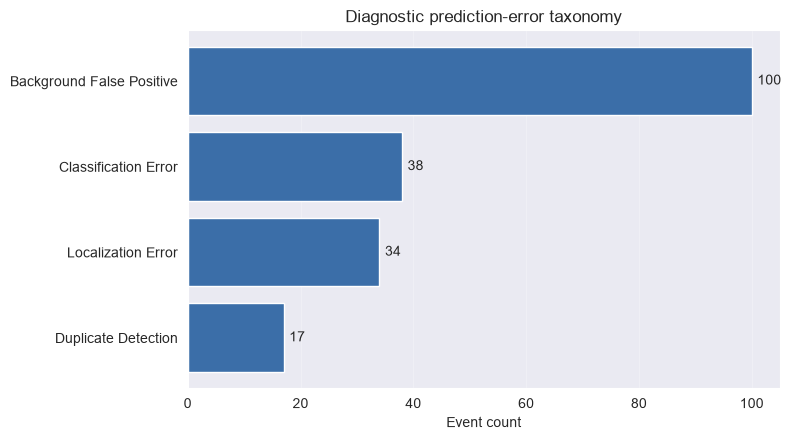


FALSE-POSITIVE SEMANTICS
Canonical fixed-point FP : 181
Caries canonical share   : 83.4%
Diagnostic taxonomy      : separate class-agnostic association


In [35]:
FALSE_POSITIVES, DIAGNOSTIC_FP_BY_TYPE, CANONICAL_TOTAL_FP, CARIES_FP_SHARE = aggregate_false_positive_diagnostics(EVENTS, PER_CLASS_VIEW)
DIAGNOSTIC_PREDICTION_ERRORS = aggregate_diagnostic_prediction_errors(EVENTS)

display(PER_CLASS_VIEW[["class_name", "FP"]].style.hide(axis="index"))
plot_canonical_false_positives(PER_CLASS_VIEW)

display(DIAGNOSTIC_PREDICTION_ERRORS[["Event", "Count"]].style.hide(axis="index"))
plot_diagnostic_fp_taxonomy(DIAGNOSTIC_PREDICTION_ERRORS)

print_section("FALSE-POSITIVE SEMANTICS", [
    ("Canonical fixed-point FP", CANONICAL_TOTAL_FP),
    ("Caries canonical share", f"{CARIES_FP_SHARE:.1%}"),
    ("Diagnostic taxonomy", "separate class-agnostic association"),
])

**Interpretation.** Caries contributes 151 of 181 canonical fixed-operating-point false positives, or 83.4%. It is therefore the main source of false alarms at the frozen operating point. That aggregate must not erase the diagnostic distinction between background responses, duplicates, localization failures, and spatially matched class disagreements.

## 8. Object-size analysis

**Question.** Is Recall associated with relative bounding-box area?

**Method.** Group ground-truth objects using the project-level relative-area bins and retain support counts.

The project uses relative bounding-box area, not COCO pixel-area categories:

$$
r=\frac{w_{box}h_{box}}{W_{image}H_{image}},\qquad
\text{small}:r<0.01,\quad
\text{medium}:0.01\leq r<0.05,\quad
\text{large}:r\geq0.05.
$$

Recall is computed using diagnostic true positives associated with each ground-truth object. A zero-sample large category is reported as unavailable rather than plotted as zero recall.

size_category,gt_count,tp,fn,recall
small,167.000000,52.000000,115.000000,0.3114
medium,372.000000,170.000000,202.000000,0.4570
large,0.000000,0.000000,0.000000,no GT samples


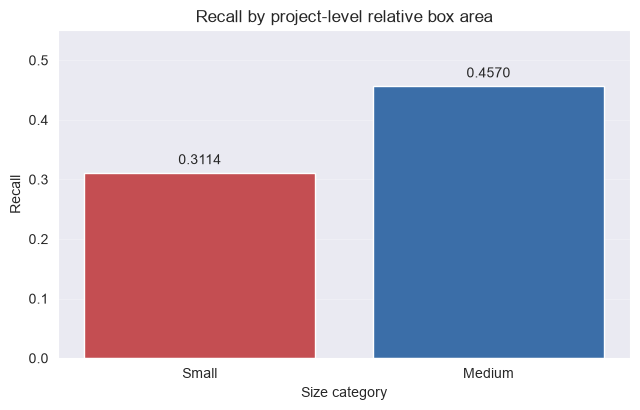

In [36]:
GT_OBJECTS, SIZE_ANALYSIS = aggregate_size_diagnostics(RECORDS, EVENTS)
display(SIZE_ANALYSIS.style.format({"recall": lambda value: "no GT samples" if pd.isna(value) else f"{value:.4f}"}).hide(axis="index"))
plot_size_recall_clean(SIZE_ANALYSIS)

**Interpretation.** Small-object Recall is 0.3114 (52 of 167), compared with 0.4570 (170 of 372) for medium objects. No ground-truth box falls in the project-level large bin, so large-object behavior cannot be estimated. The association between size and misses is descriptive, not causal; class distribution, morphology, image context, confidence, and annotation characteristics may interact with object area.

## 9. Classification and localization errors

**Question.** When regions are found, are failures primarily class assignment or box overlap?

**Method.** Separate high-IoU class disagreements, sub-threshold correct-class overlaps, and true-positive IoU distributions.

Classification errors are predictions that localize an object at IoU at least 0.50 but assign the wrong class. The matrix below contains only those spatially matched disagreements; background is excluded. Localization errors instead use correct-class candidates in the fixed descriptive interval $0.10\leq\mathrm{IoU}<0.50$.

class_name,TP_count,median_TP_IoU
Impacted,74,0.808
Caries,124,0.848
Periapical Lesion,2,0.854
Deep Caries,22,0.823


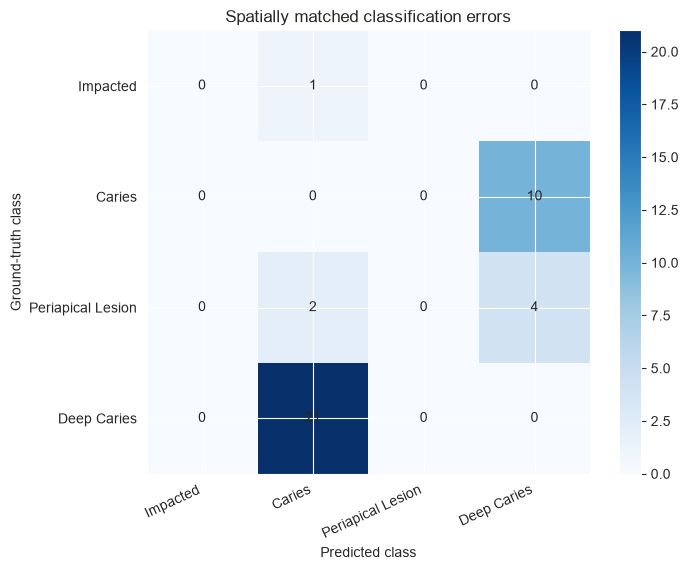

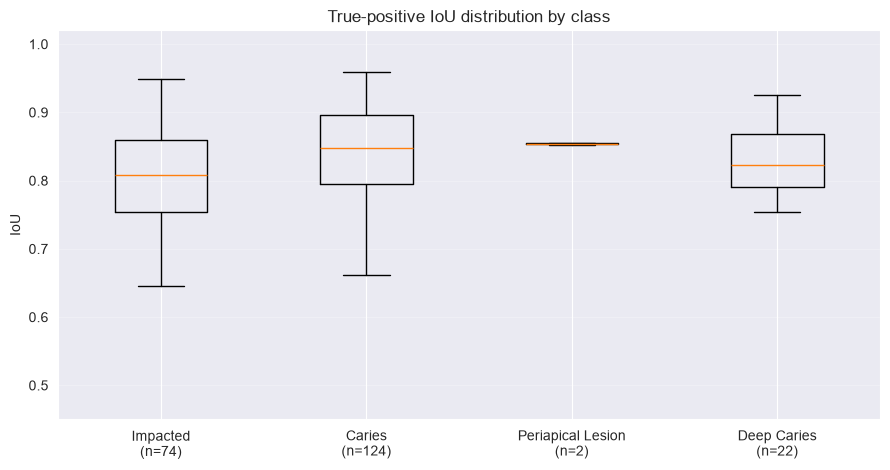


CLASSIFICATION AND LOCALIZATION
Classification errors : 38
Localization errors   : 34
TP IoU observations   : 222


In [37]:
CLASSIFICATION_ERRORS, LOCALIZATION_ERRORS, CLASSIFICATION_CONFUSION, TP_IOU, TP_LOCALIZATION = aggregate_classification_localization(EVENTS)
display(TP_LOCALIZATION.style.format({"median_TP_IoU": "{:.3f}"}).hide(axis="index"))
plot_classification_confusion(CLASSIFICATION_CONFUSION)
plot_tp_iou_distribution(TP_IOU)
print_section("CLASSIFICATION AND LOCALIZATION", [
    ("Classification errors", len(CLASSIFICATION_ERRORS)),
    ("Localization errors", len(LOCALIZATION_ERRORS)),
    ("TP IoU observations", len(TP_IOU)),
])

**Interpretation.** The taxonomy contains 38 classification and 34 localization errors, compared with 279 false negatives. Median IoU among successful detections is approximately 0.808 for Impacted, 0.848 for Caries, 0.854 for Periapical Lesion, and 0.823 for Deep Caries. The Periapical estimate is based on only two true positives and is therefore not robust class-level evidence. When the detector finds the correct object, overlap is generally reasonably high; missed objects dominate more strongly than localization failures:

$$279\ \text{FN} \gg 34\ \text{localization errors}.$$

## 10. Confidence diagnostics

**Question.** How do frozen candidate scores behave by predicted class?

**Method.** Summarize all persisted candidates, their ECDFs, and survival at the fixed 0.50 threshold.

All frozen candidate scores are examined relative to the already-fixed threshold. The plot is descriptive and does not evaluate alternative thresholds.

predicted_class,predictions,median,mean,maximum
Impacted,495,0.295,0.334,0.613
Caries,2224,0.299,0.333,0.687
Periapical Lesion,332,0.240,0.261,0.605
Deep Caries,1054,0.252,0.282,0.662


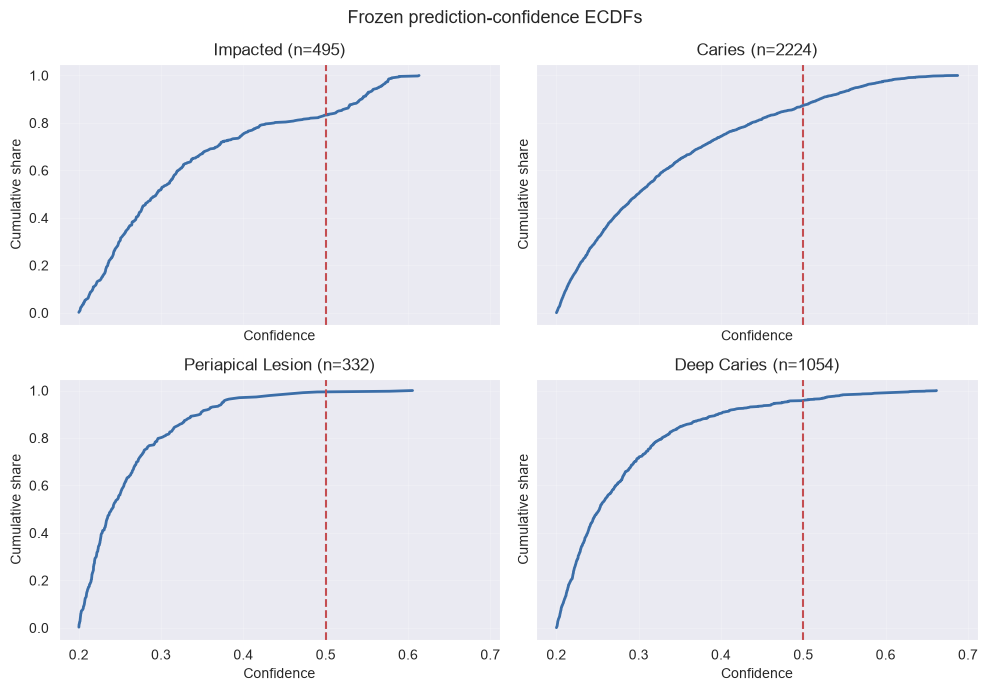

predicted_class,candidate_predictions,accepted_predictions,survival_fraction
Impacted,495,83,16.77%
Caries,2224,281,12.63%
Periapical Lesion,332,2,0.60%
Deep Caries,1054,45,4.27%


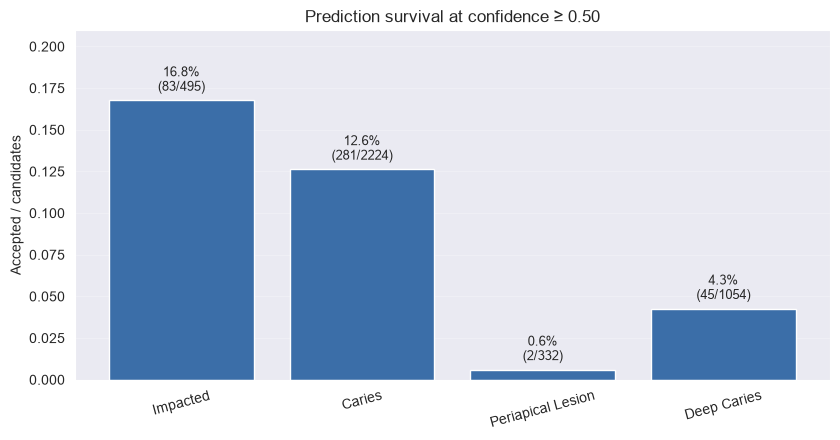


CONFIDENCE DIAGNOSTICS
Frozen threshold           : 0.50
Periapical below threshold : 330/332
Threshold search           : NOT PERFORMED


In [38]:
CONFIDENCE_TABLE, CONFIDENCE_BY_CLASS, CONFIDENCE_SURVIVAL, PERIAPICAL_CANDIDATES, PERIAPICAL_BELOW = aggregate_confidence_diagnostics(RECORDS)
display(CONFIDENCE_BY_CLASS.style.format({"median": "{:.3f}", "mean": "{:.3f}", "maximum": "{:.3f}"}).hide(axis="index"))
plot_confidence_ecdfs(CONFIDENCE_TABLE)

display(CONFIDENCE_SURVIVAL.style.format({"survival_fraction": "{:.2%}"}).hide(axis="index"))
plot_confidence_survival(CONFIDENCE_SURVIVAL)

print_section("CONFIDENCE DIAGNOSTICS", [
    ("Frozen threshold", f"{CONFIDENCE_THRESHOLD:.2f}"),
    ("Periapical below threshold", f"{PERIAPICAL_BELOW}/{PERIAPICAL_CANDIDATES}"),
    ("Threshold search", "NOT PERFORMED"),
])

**Interpretation.** The detector produces 332 Periapical candidates, but 330 fall below confidence 0.50. This helps explain why few Periapical detections survive the frozen operating point. It does not establish that lowering the threshold would improve deployment behavior; any future calibration must be designed with validation data and independently evaluated.

## 11. Qualitative failure cases

**Question.** What do objectively selected representative failures look like?

**Method.** Select cases programmatically from the diagnostic event and image-burden tables.

Case selection is programmatic rather than aesthetically curated. It covers a strong true-positive image, an FN-heavy image, a background false positive, a classification error, a localization error, a small-object miss, a Periapical miss, and a Caries false-positive-heavy image. All panels use persisted CPU predictions.

selection_reason,image_id,file_name,event_type,confidence,iou
Strongest clean true-positive image,230,train_540.png,true_positive,0.652,0.940
Highest false-negative image,190,train_462.png,false_negative,0.348,0.520
Highest prediction-error image,266,train_26.png,classification_error,0.588,0.886
Periapical false-negative,164,train_510.png,false_negative,0.602,0.000
Caries false-positive-heavy image,155,train_485.png,background_false_positive,0.576,0.000
Classification-error case,63,train_592.png,classification_error,0.661,0.836
Localization-error case,392,train_244.png,localization_error,0.583,0.102
Small-object miss,63,train_592.png,false_negative,0.497,0.514


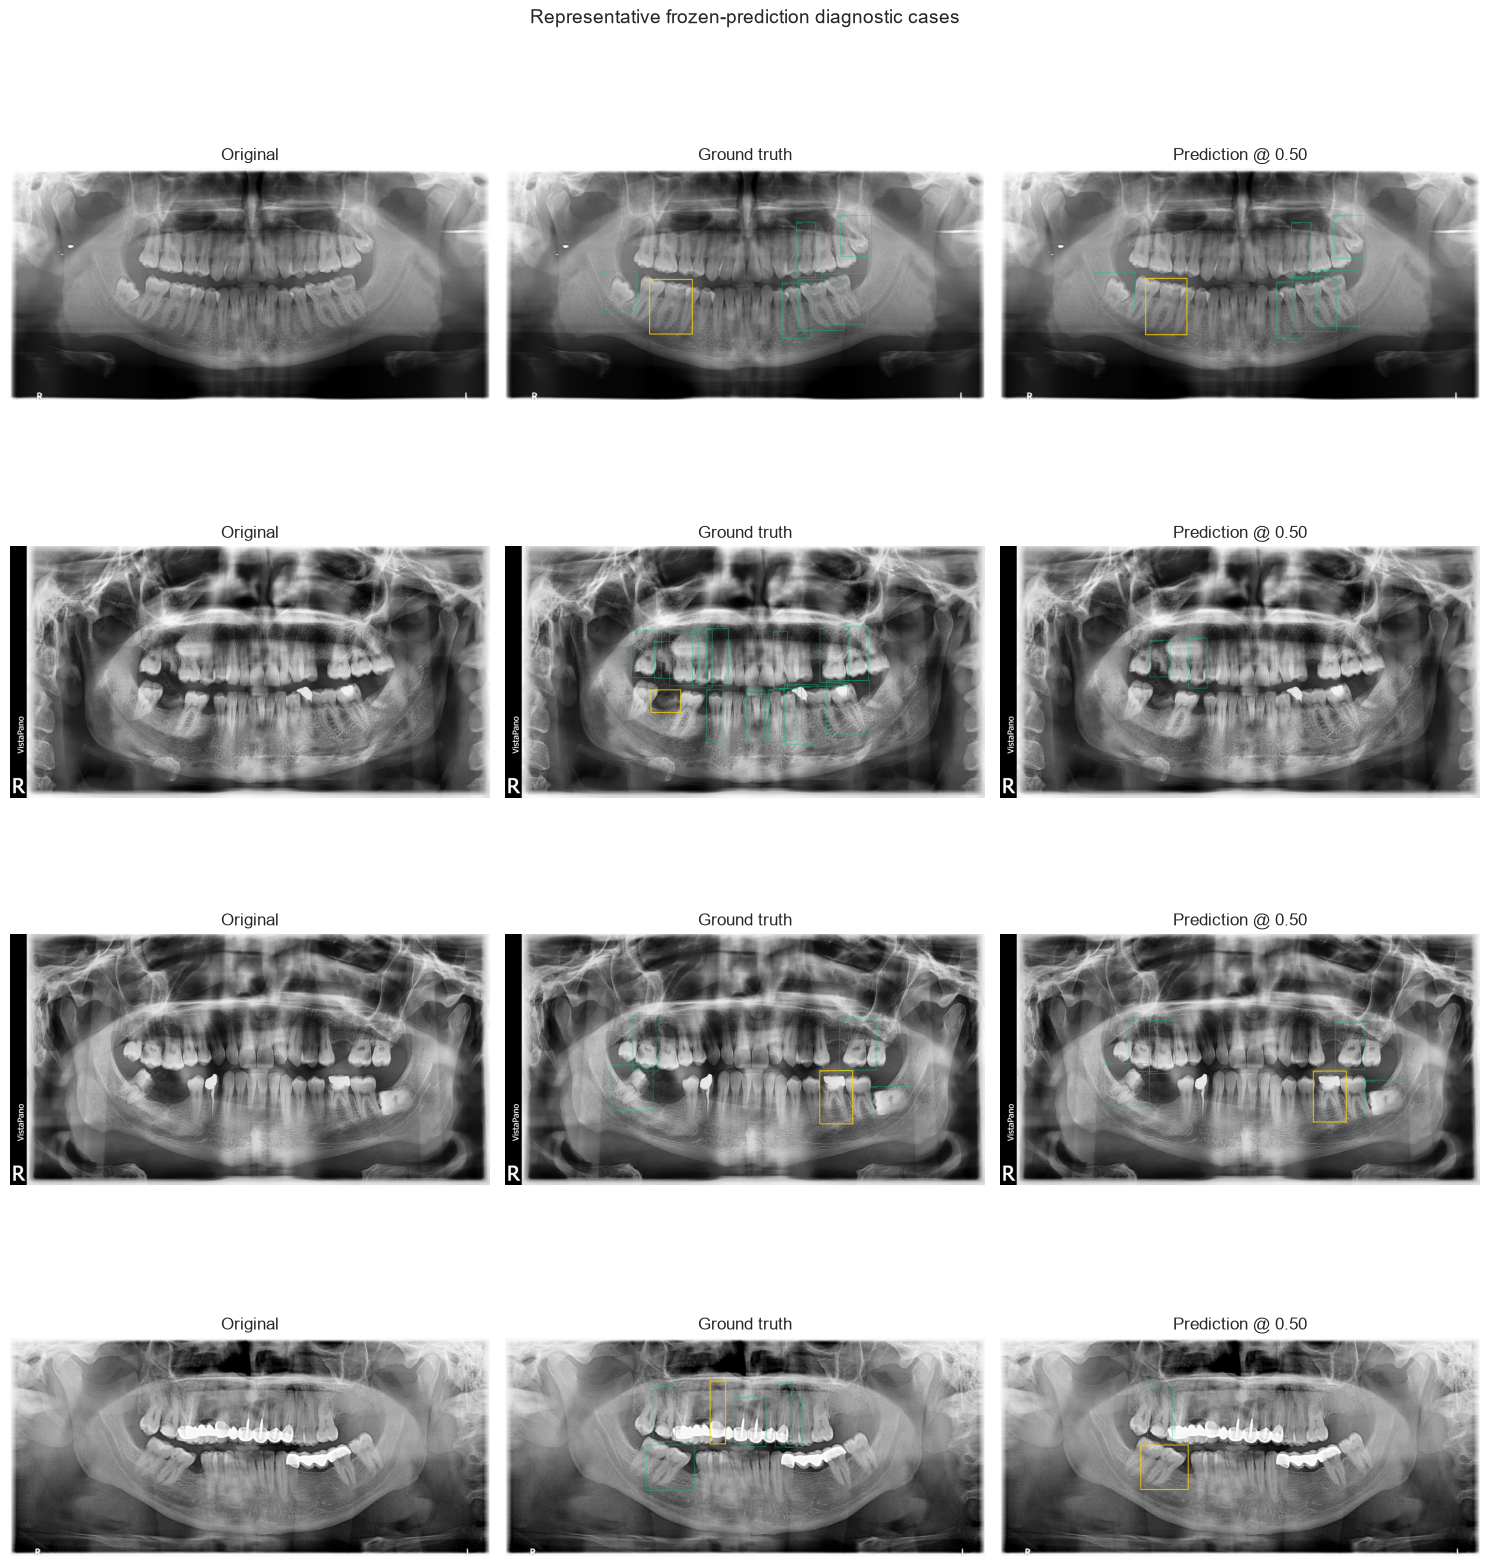

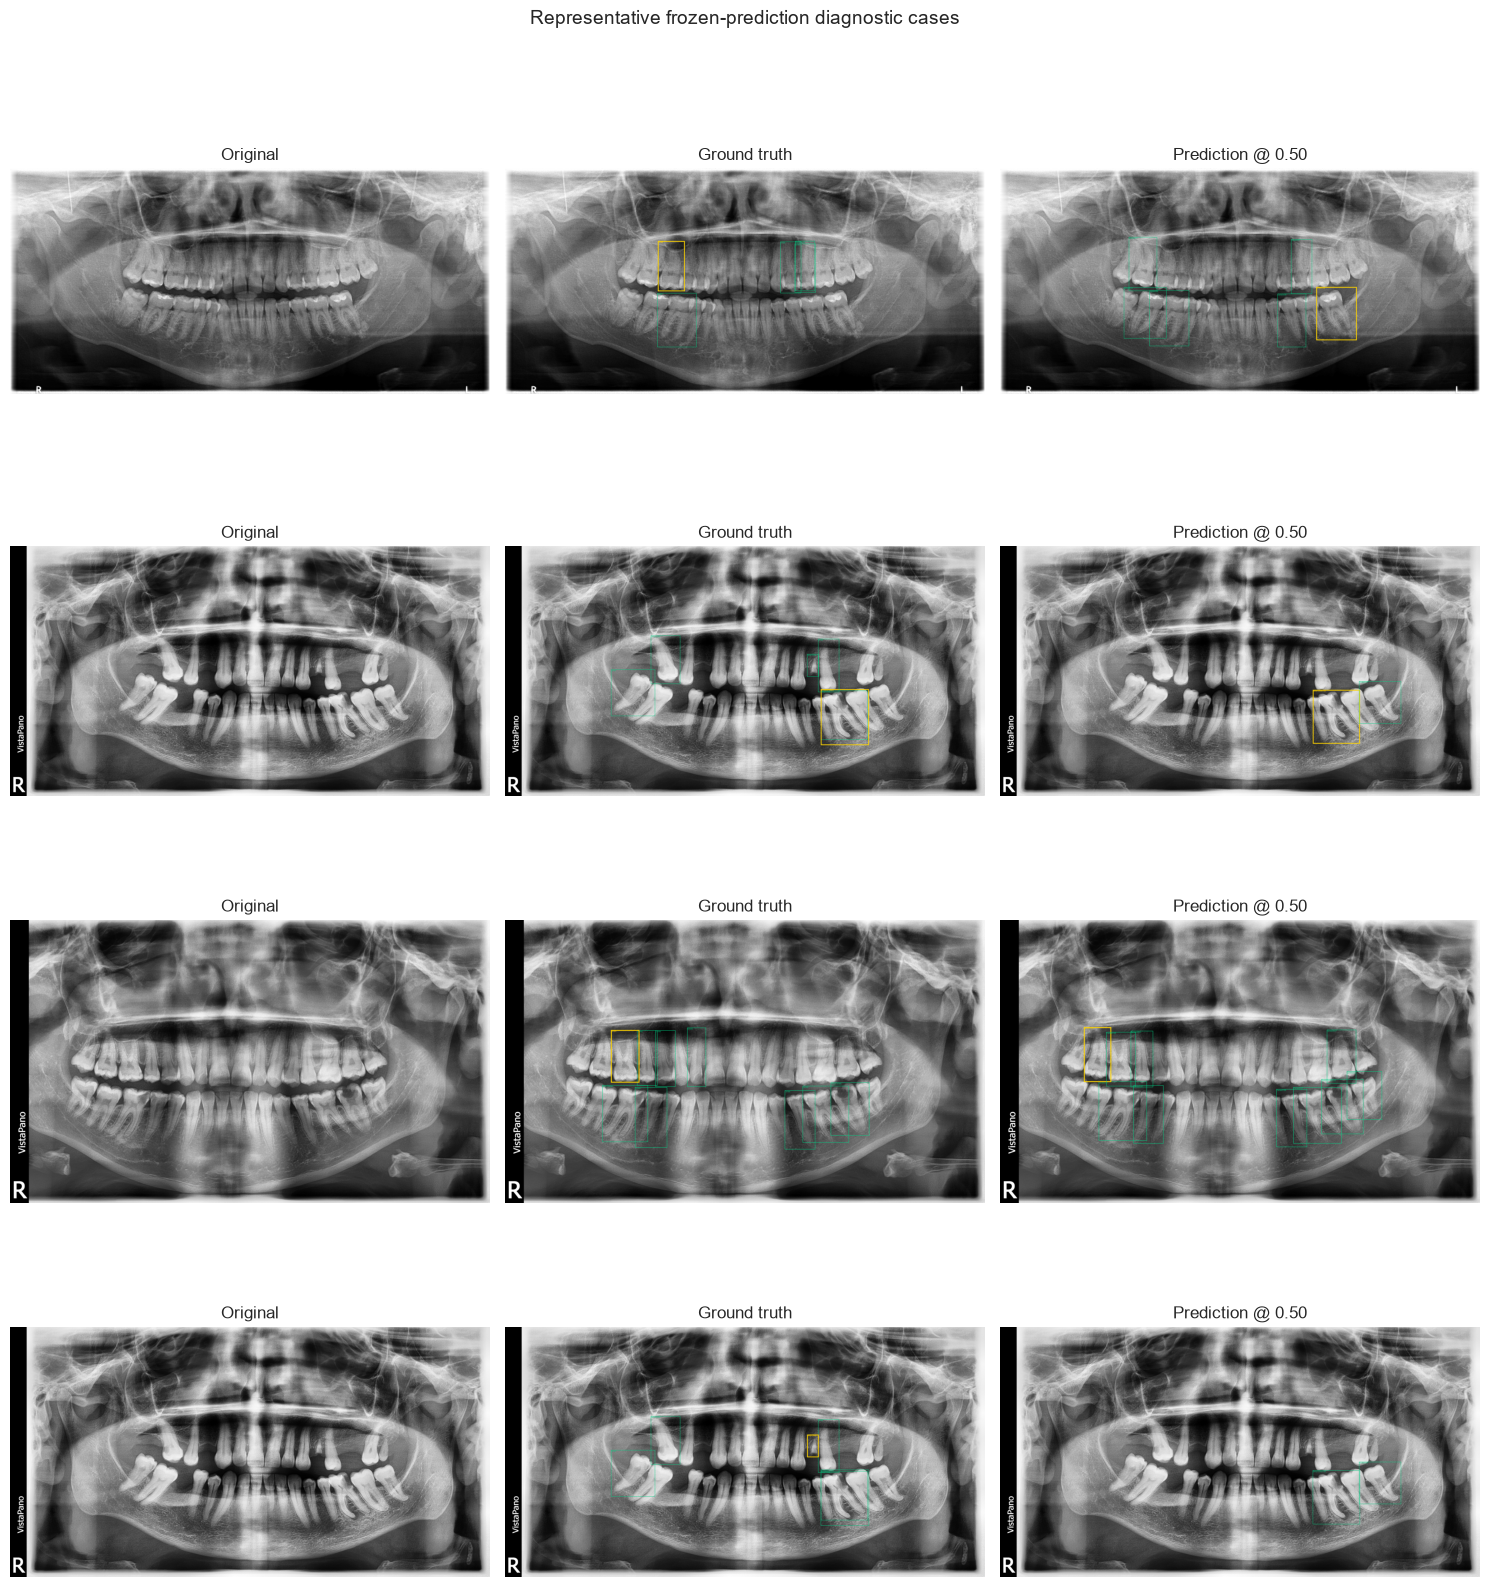

In [39]:
QUALITATIVE_CASES = select_representative_cases(EVENTS, RECORDS)
QUALITATIVE_CASE_TABLE = pd.DataFrame([
    {
        "selection_reason": case["selection_reason"], "image_id": case["image_id"],
        "file_name": case["file_name"], "event_type": case["event_type"],
        "confidence": case["confidence"], "iou": case["iou"],
    }
    for case in QUALITATIVE_CASES
])
display(QUALITATIVE_CASE_TABLE.style.format({"confidence": "{:.3f}", "iou": "{:.3f}"}).hide(axis="index"))
plot_case_gallery(QUALITATIVE_CASES, FIGURE_DIR / "representative_failure_cases.png")

**Interpretation.** The galleries distinguish the original radiograph, complete ground truth, and accepted frozen predictions. Yellow boxes identify the selected event where that object survives in the displayed panel. The examples illustrate the tabulated taxonomy; they do not replace aggregate evidence.

## 12. Main failure modes

**Question.** Which findings define the final diagnostic profile?

**Method.** Combine already-computed tables without recomputing matching or hardcoding results.


image_id,file_name,GT count,candidate predictions,accepted predictions,true_positive,false_negative,background_false_positive,classification_error,localization_error,duplicate_detection,total diagnostic errors,diagnostic recall
190,train_462.png,16,64,2,2,14,0,0,0,0,14,0.125000
255,train_477.png,14,59,5,3,10,0,1,1,0,12,0.214286
536,train_481.png,14,81,6,4,10,0,0,1,1,12,0.285714
202,train_391.png,17,100,10,7,9,1,1,1,0,12,0.411765
229,train_658.png,11,32,1,1,10,0,0,0,0,10,0.090909
388,train_507.png,11,52,9,4,5,0,2,1,2,10,0.363636
154,train_255.png,11,17,2,2,9,0,0,0,0,9,0.181818
239,train_696.png,10,28,4,2,7,1,1,0,0,9,0.200000
556,train_192.png,11,57,5,3,7,0,1,0,1,9,0.272727
597,train_55.png,8,36,5,1,5,0,2,0,2,9,0.125000


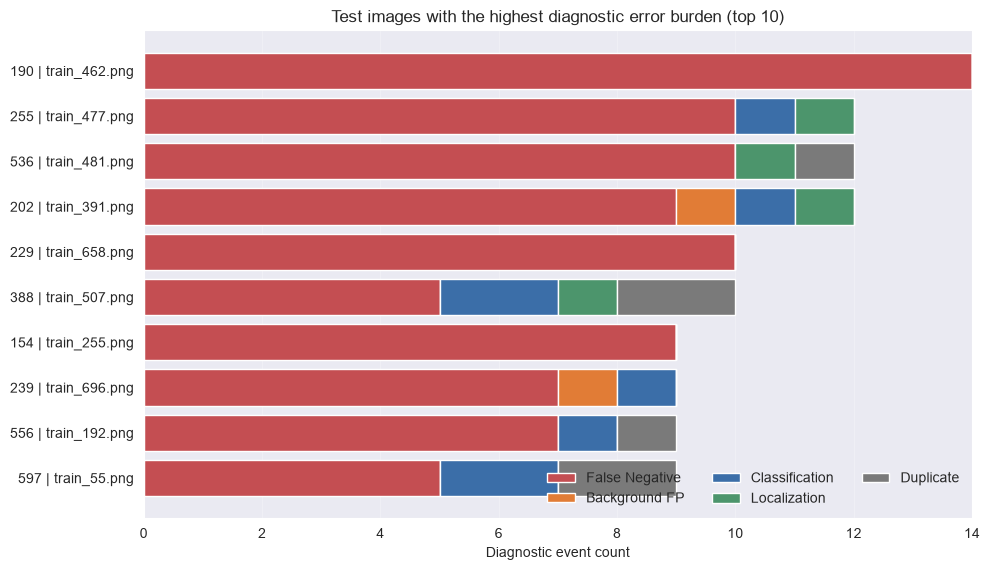


DOMINANT FAILURE MODES
Most frequent event   : False Negative (279)
Highest FN rate class : Periapical Lesion (0.9231)
Primary FP class      : Caries (151)
Lower size recall     : Small (0.3114)
Derived artifacts     : C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\error_analysis
Status                : COMPLETE


In [41]:
IMAGE_DIFFICULTY = build_image_difficulty_table(RECORDS, EVENTS)
display(IMAGE_DIFFICULTY.head(10).style.hide(axis="index"))
plot_image_error_burden(IMAGE_DIFFICULTY, top_n=10)

large_recall = SIZE_ANALYSIS.loc[SIZE_ANALYSIS.size_category == "large", "recall"].iloc[0]
dominant_event = ERROR_TAXONOMY.loc[ERROR_TAXONOMY.Count.idxmax()]
highest_fn_rate = FN_BY_CLASS.loc[FN_BY_CLASS["FN rate"].idxmax()]
primary_fp_class = PER_CLASS_VIEW.loc[PER_CLASS_VIEW.FP.idxmax()]

ERROR_SUMMARY = {
    "final_model": EXPECTED_EXPERIMENT_ID,
    "prediction_source": "test_predictions.pt",
    "image_count": len(RECORDS),
    "fixed_confidence_threshold": CONFIDENCE_THRESHOLD,
    "fixed_iou_threshold": IOU_THRESHOLD,
    "diagnostic_localization_iou_floor": LOCALIZATION_IOU_FLOOR,
    "event_counts": ACTUAL_EVENT_COUNTS,
    "dominant_failure_mode": dominant_event.event_type,
    "easiest_class": str(PER_CLASS.loc[PER_CLASS.AP50_95.idxmax(), "class_name"]),
    "hardest_class": str(PER_CLASS.loc[PER_CLASS.AP50_95.idxmin(), "class_name"]),
    "small_object_recall": float(SIZE_ANALYSIS.loc[SIZE_ANALYSIS.size_category == "small", "recall"].iloc[0]),
    "medium_object_recall": float(SIZE_ANALYSIS.loc[SIZE_ANALYSIS.size_category == "medium", "recall"].iloc[0]),
    "large_object_recall": None if pd.isna(large_recall) else float(large_recall),
    "caries_share_canonical_fp": CARIES_FP_SHARE,
    "periapical_candidates_below_threshold": PERIAPICAL_BELOW,
    "periapical_candidate_count": PERIAPICAL_CANDIDATES,
    "model_loaded": False,
    "inference_rerun": False,
    "threshold_tuned": False,
}
save_error_analysis_artifacts(
    ERROR_TAXONOMY, PER_CLASS_VIEW, FALSE_NEGATIVES, DIAGNOSTIC_PREDICTION_ERRORS,
    FALSE_POSITIVES, SIZE_ANALYSIS, CLASSIFICATION_CONFUSION,
    CLASSIFICATION_ERRORS, LOCALIZATION_ERRORS, TP_LOCALIZATION,
    CONFIDENCE_BY_CLASS, CONFIDENCE_SURVIVAL, IMAGE_DIFFICULTY,
    QUALITATIVE_CASE_TABLE, ERROR_SUMMARY,
)
print_section("DOMINANT FAILURE MODES", [
    ("Most frequent event", f'{dominant_event.Event} ({int(dominant_event.Count)})'),
    ("Highest FN rate class", f'{highest_fn_rate.Class} ({highest_fn_rate["FN rate"]:.4f})'),
    ("Primary FP class", f'{primary_fp_class.class_name} ({int(primary_fp_class.FP)})'),
    ("Lower size recall", f'Small ({ERROR_SUMMARY["small_object_recall"]:.4f})'),
    ("Derived artifacts", ERROR_DIR),
    ("Status", "COMPLETE"),
])

**Interpretation.** False negatives are the dominant limitation. Periapical Lesion has the highest FN rate, Caries produces most canonical false positives, and small objects have lower Recall than medium objects under the project bins. Classification errors remain material, while localization errors and duplicates are secondary. Dataset size, class imbalance, morphology, annotation uncertainty, and the absence of large-bin examples limit stronger subgroup claims.

## 13. Future-development implications

These findings define hypotheses for a separate future cycle, not modifications to the frozen detector. Legitimate directions include acquiring or reviewing data for weak classes, class-aware sampling, targeted augmentation, focused small-object studies, and confidence calibration performed exclusively on development/validation data. Periapical candidates warrant particular study because most scores lie below the current frozen threshold.

Any redesigned system influenced by these test findings requires a new independent final-evaluation protocol. The present test split has now contributed diagnostic knowledge and cannot honestly be marketed as unseen evidence for the next cycle.

## 14. Final diagnostic summary and deployment handoff

The experimental ML sequence is now complete:

$$
\text{Baseline}
\rightarrow \text{Architecture screening}
\rightarrow \text{Model comparison}
\rightarrow \text{FCOS refinement}
\rightarrow \text{Frozen final model}
\rightarrow \text{Final test evaluation}
\rightarrow \text{Post-hoc error analysis}
\rightarrow \text{Deployment}.
$$

The final test result remains unchanged. Notebook 08 derived all diagnostics from the single persisted CPU inference artifact, with no model loading, GPU inference, checkpoint reselection, or threshold adjustment. Deployment must preserve the frozen preprocessing and class mapping, expose confidence without presenting it as clinical certainty, and account for the documented high miss rate—especially for Periapical Lesion. This remains an experimental detector, not a clinical diagnostic system.